# DSP Methodology

In [1]:
%matplotlib widget

import sys; sys.path.insert(0, '../../../research')
from dsplot.figures import figure_1, figure_2_4_1, figure_2_4_2, figure_2_4_3, figure_2_5, figure_2_6


## 1. Motivations
- To visualize an audio signal effectively, we need a precise method for representing it's behavior
- Specifically, we want to know **what** frequencies are present and **when** they occur in the signal 
- This is the primary motivation for finding a highly accurate **time-frequency** analysis method 
  - The textbook approach is the **Fourier Analysis**, but in this context it has limitation
  - The more recently popularized **Wavelet Analysis** is much better suited for this kind of task
- Both are built on the same foundation - **signal decomposition** 
- Beginning with simple examples, we will build up to a comprehensive and intuitive understanding of how these methods actually work, and explore the different areas where they excel and fall short → Section 2

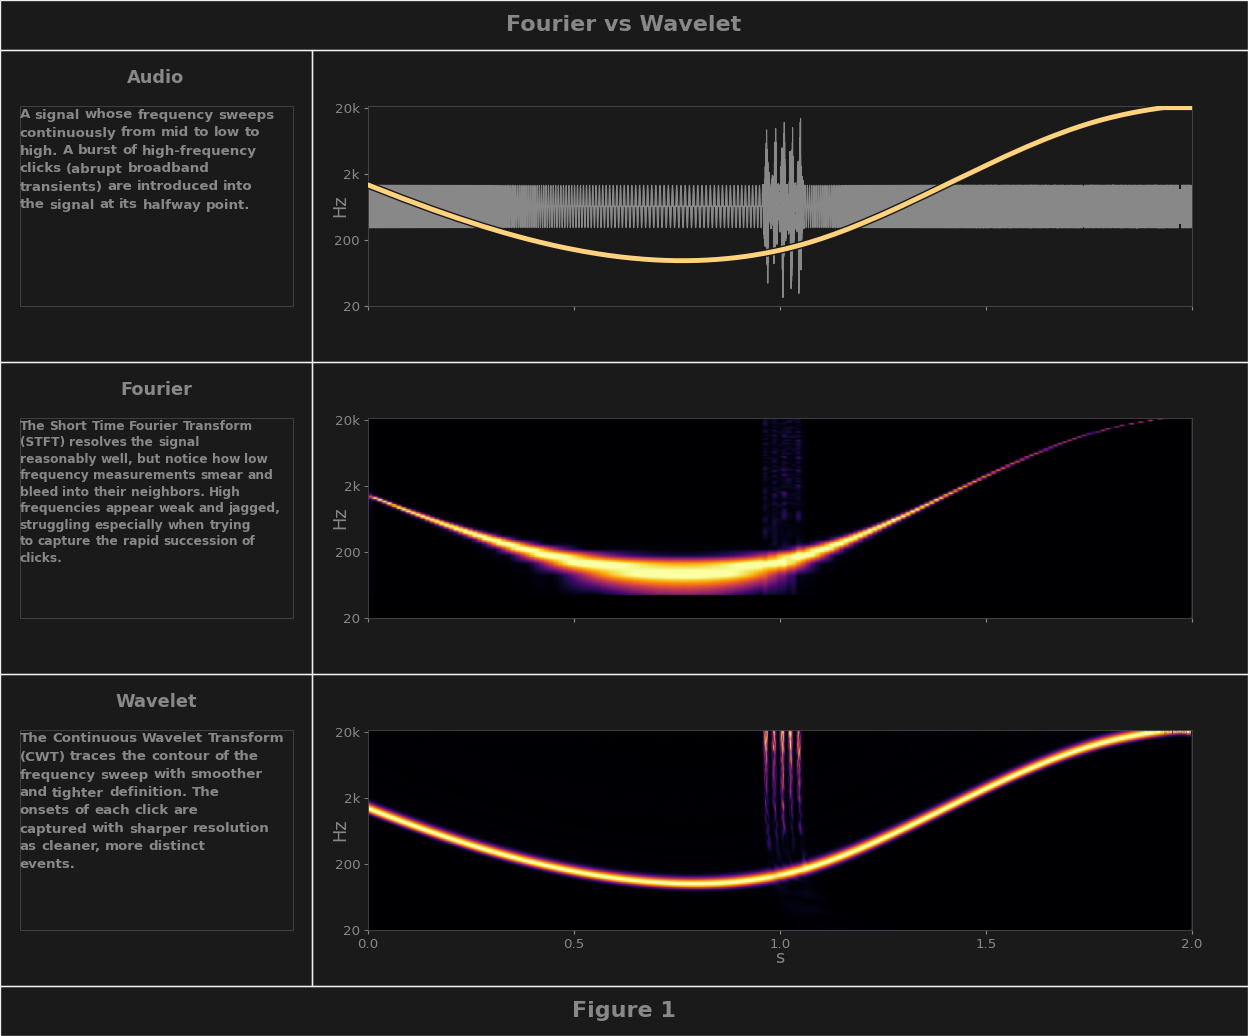

In [2]:
figure_1()

---

## 2. Foundations

### 2.1 Signal Decomposition - The Goal

- The end goal is to **decompose** any given signal into its fundamental **components**
- In simpler terms, we want to break a signal down into its **basic building blocks** and see how much of each "block" exists in the signal originally 
- This is like trying to unmix a can of paint to figure out how much of each color ingredient contributed to the overall color of the paint - where would you even begin?
- This type of problem motivates us to do two things:
    1. **Define what a signal's fundamental components are** 
    2. **Measure the presence of each component in the signal** 
- This is where the **Inner Product** comes into play - it's a general-purpose tool for measuring signal components, and we will explore these two motivations in different contexts


### 2.2 Inner Product - The Tool

- The **Inner Product** gives us a generic way to compare and compute a "**similarity score**" between
    - A function **f** - the signal 
    - A reference function **g** - something that embodies the signal properties we want to measure 

<div align="center">

$$
\langle \, 
\mathbf{f} \, , \, 
\mathbf{g} \,
\rangle 
$$

<em>Inner Product Notation</em>

</div>

- The result is a measurement of how **correlated** these function are, indicating their **similarity**
- But to understand how this actually works, it's helpful to see how the Inner Product operates in its simplest form - the **Dot Product**



### 2.3 Dot Product - The Basic Case

- The Inner Product generalizes what the **Dot Product** does to **vectors** in $\mathbb{R}^n$ 
- All this means is we will just be applying these concepts to just plain, regular, real numbers - no imaginary or abstract numbers in weird math domains (yet)
- As long as you can do basic **multiplication** and **addition**, it's really not too bad

<div align="center">

$$
\vec{a} \cdot\vec{b} = \sum_{i=0}^{n} a_i b_i
$$

<em>Dot Product Notation</em>
</div>

- In plain English this is called a **sum of products** - **multiply** each term in vector **a** with each term in vector **b** and then **add** them all together
    <!-- 1. Take the first term from **a** 
    2. Take the first term from **b**
    3. **Multiply** them together
    4. Repeat 1-3 for each pair of terms
    5. **Add** up all the multiplied terms together -->

<div align="center">

$$
\vec{a} = 
    ( \,
    a_0 \, , \,
    a_1 \, , \,
    a_2 \, , \, 
    \ldots \, , \,
    a_n \, )
$$

</div>

<div align="center">

$$
\vec{b} = 
    ( \,
    b_0 \, , \,
    b_1 \, , \,
    b_2 \, , \, 
    \ldots \, , \,
    b_n \, )
$$

</div>

<div align="center">

$$
\vec{a} \cdot\vec{b} = 
    a_0 \cdot b_0 \, + \,
    a_1 \cdot b_1 \, + \,
    a_2 \cdot b_2 \, + \, 
    \ldots \, + \,
    a_n \cdot b_n \, 
$$

<em> Dot Product Operation </em>
</div>

- But what does this result even really mean? And what does this operation even really do? 
- Spoiler, the result indicates how **parallel** vectors **a** and **b** are - this is the key insight to understanding that the Dot Product operation measures **"similarity"** by  calculating how **aligned** **a** and **b** are in terms of their "parallel-ness"
- This clicks more visually during **Vector Projection**, our first attempt at any form of **decomposition**


### 2.4 Vector Projection - The Geometric Interpretation

#### 2.4.1 Projecting onto a Reference Direction

- A **vector** can be thought of as an **arrow** described by two of its properties
  - **magnitude** - how long it is 
  - **direction** - where it points

- To **decompose** a vector, or break it down into its most basic components, we **project it along** the directions of **all the dimensions** it exists in - **Figure 2.4.1.a**
  - Since **a** is defined by two dimensions, think of it like the vector casting its **"shadows"** onto the x and y axes 
  - Notice how as **a** grows or shrinks in any particular direction, the "shadow" **aligned** with each dimension compensates itself accordingly
  - This illustrates how projecting **a** onto these axes reveals the components of **a** that are **parallel** to x and y 

- We are able to designate these "shadow" lengths as the vector's **basic components** since they
  1. **Can be combined in any order** to reconstruct the original - **Figure 2.4.1.b** 
      - Stacking the components tip-to-tail rebuilds vector **a** 
      - Notice when recombining these components - either starting with x first and then y, or y first and then x, regardlessly, you still end up with the **original**
  2. **Measure independent information** about the original - **Figure 2.4.1.c**
      - Being independent of each other means knowing the value of one component **tells you nothing** about the other 
      - Notice how as the vector sweeps through each direction, the other direction's component is fully unaware and unaffected 
      - Since they point at **right angles** to each other, each dimension is **unrelated** -.
       **x cannot measure any information that y measures** and vice versa - we call this being **orthogonal**

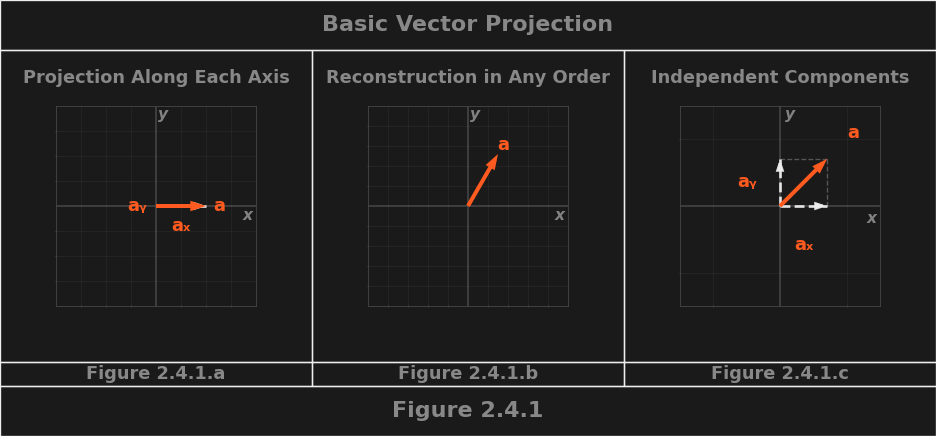

In [3]:
figure_2_4_1() # have 241c pause one frame in between sweeping each component

#### 2.4.2 Projecting onto Another Vector

- So far we've established how projection reveals a vector's **parallel component**  
  - Previously, we projected onto the directions of the familiar **x and y axes** to reveal the components **parallel to them** 
  - Similarly, we can project onto the direction of **any other vector** to reveal the component **parallel to it**
  - This involves the two vectors in an interesting relationship 

- The relative **angle** between **a** and **b** has direct control of the projected parallel component - **Figure 2.4.2.a**
  - Here you can see its **size and direction** track the **alignment** of the two vectors by 
    - Growing **large in one direction** when they point **similarly parallel** 
    - Reducing to **zero** when they point perpendicularly (perfectly **not parallel**)
    - Growing **large in the other direction** when they point **oppositely parallel**

- This relationship should sound familiar
  - Earlier, we claimed performing the Dot Product on two vectors produces a "similarity score" for the same thing
  - Yet the operation itself is deceptively simple - all you do is **multiply** corresponding terms and **add** them together
  - How does a simple **multiply-and-add** operation, performing *no visible trig*, capture a relationship clearly so dependent on the vectors' relative angle?

- It turns out the Dot Product and Vector Projection are two views of a shared geometric relationship - **Figure 2.4.2.b**
  - Notice how they both produce the **same result** even as the angle changes
  - Apparently, the Dot Product can be derived from the **triangle** formed by the vectors like in [this video](https://youtu.be/PnJoKGynu_U?si=qr-2XD9gF5MeU9n5) - it abides the age-old [Law of Cosines](https://www.reddit.com/media?url=https%3A%2F%2Fcf.preview.redd.it%2Flaw-of-cosines-v0-arli6kvsxkga1.jpg%3Fwidth%3D1080%26crop%3Dsmart%26auto%3Dwebp%26s%3D6fd1802a88aa4c78470f2878b22f684e43d8765b) which is like the Pythagorean Theorem but for any triangle
  - Basically, as the angle between the vectors changes, their **x** and **y** components are simultaneously **changing with it**
  - This means the Dot Product already has this precious angle **baked into** the components **before** operating on them directly

<div align="center">

$$
\vec{a} \cdot \vec{b}
=
|\vec{a}| |\vec{b}| \cos(\theta)
=
a_x b_x + a_y b_y
$$

<em>2D Dot Product - Cosine and Component Form</em>

</div>

- This lets us use the Dot Product and Vector Projection as different framings of the same relationship - parallelism
  - Both measure the **alignment** of two vectors, which we said reflects their **similarity**
    - Projection reveals this geometrically through **trig** using each vector as a whole
    - The Dot Product computes it using a simple **sum of products** on their individual components
  - Naturally, this relationship exists beyond two dimensions

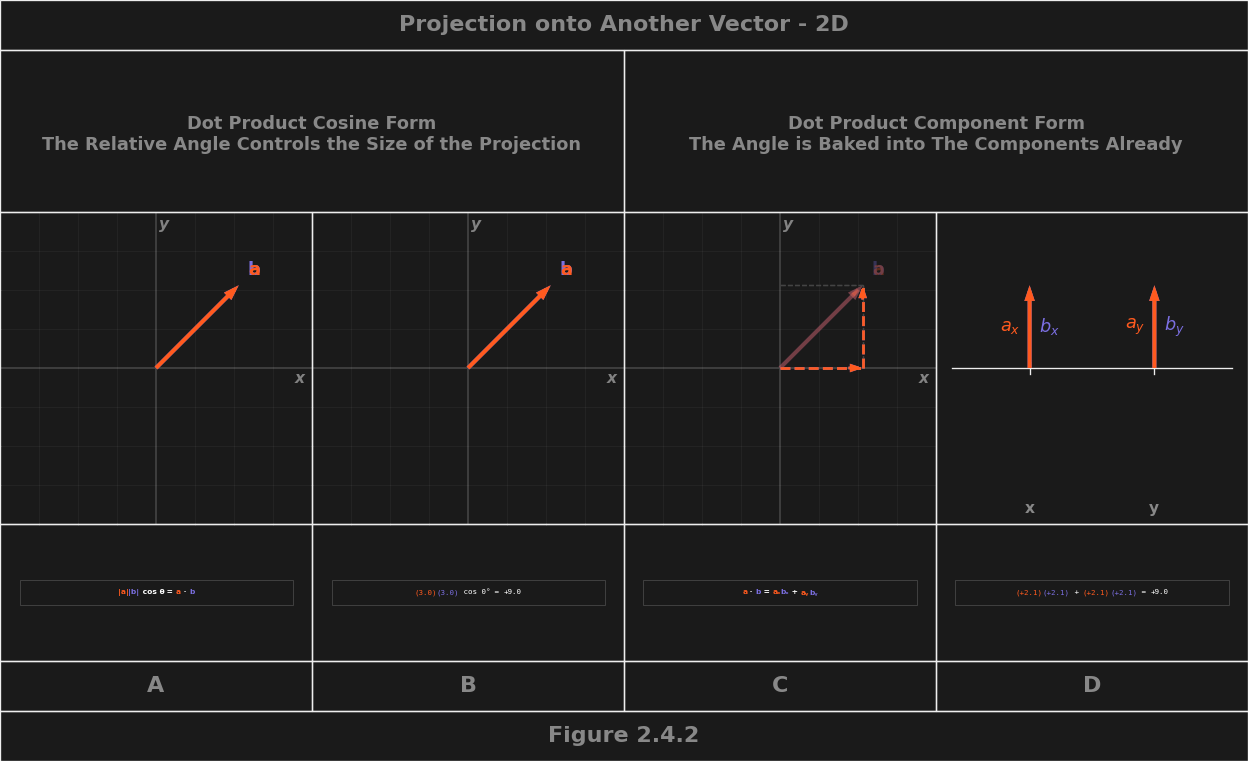

In [4]:
figure_2_4_2()

#### 2.4.3 Projection in 3D and Beyond

- The Vector Projection and Dot Product equivalence also extends to vectors described by **three** dimensions - **Figure 2.4.3.a**
  - To add a third dimension, we orient the z axis at **right angles** to the others x and y 
  - It's important they are all **perpindicular** - as we said in §2.4.1 this relationship relies on them all being **independent** of one other
  - This way, the parallel projection and triangle relationship still occur here, however, the angle becomes tough to isolate even with trig now that it cuts through multiple planes
  - It's a lot simpler for us to just use the Dot Product on the individual components to score their similarity

- To no surprise, this relationship applies to **any number** of dimensions
  - Past three dimensions, we can no longer visualize the parallel projection - it's not visually possible to orient any more axes at right angles to the others
    - At this point, we need to **reconsider what a vector and its components really are**
    - For three dimensions, each vector is a set of three components whose values represent the independent contributions of each dimension
    - For any number of dimensions, we will treat every vector like a **set of "independent values"** instead of "dimensions"
  - The audio signals we'll be working with are all just collections of independently measured **values** sampled in time
    - Not measured along x, y, or z - just values captured at regular intervals, usually far more than three
    - Each value belongs to an **independent moment in time**, so just like for vector components, knowing the value of one **tells you nothing** about the others
    - Because of this, the Dot Product can still measure this concept of similarity and is why we even care about doing this beyond three dimensions
  - To lock this in, we'll drop the geometric view entirely and examine what the Dot Product is actually doing operationally

<!-- - To no surprise, this relationship applies to **any number** of dimensions
  - Past three dimensions, we can no longer visualize the projection - it's not visually possible to orient any more axes at right angles to the others
    - At this point, we need to reconsider what a vector and its components really are
    - For three dimensions, each vector is a set of three components whose values represent the independent contributions of each dimension
    - For any number of dimensions, we will treat every vector like a **set of "independent values"** instead of "dimensions"
  - The audio signals we'll be working with are all just collections of **independent audio samples** measured in time 
    - Not measured along x, y, or z - just a set of independently measured **values** sampled in time - usually way more than just three
    - They are all independent of each other - knowing the value of one tells you nothing about the others
    - Becasuse of this, they still abide by the Dot Product's ability to measure similarity which is why we care to go beyond three dimensions
    - We will be using this
    - What we really care about here is the concept of computing the **similarity** between two sets of these values 
    - To finally lock this in intuitively, we will examine how the Dot Product works operationally, dropping the "dimension" language -->

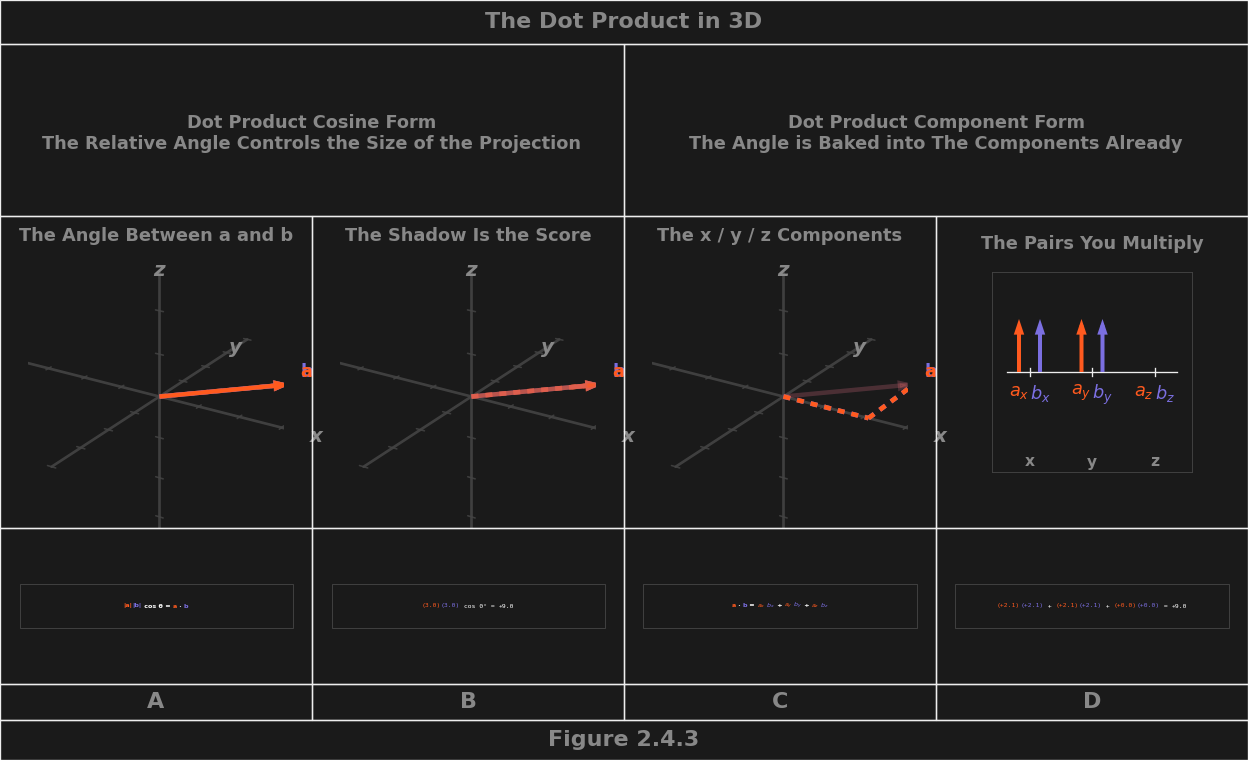

In [5]:
figure_2_4_3()

## 2.5 Sign Accumulation - The Agreement Mechanism

- The Dot Product's multiply-and-add operation measures how two sets of values **move together or apart** by assessing their total **sign agreement** 
  - This is basically what is known as **correlation** - typically we'd normalize all the values but the underlying operation is functionally the same
  - Each **product** reveals whether or not each pair of values move in the same direction or in opposition
    - When they **agree** in sign, their product **increases** the sum - making it more **positively correlated**
    - When they **disagree** in sign, their product **decreases** the sum - making it more **negatively correlated**
    - When one is **zero**, their product does **nothing** to the sum - implying **no correlation**
  - The **sum** of all these products capture the net sign agreement across every pair

  <!-- example all except one sign are the same, some are same, some are oppsoite, all except one are opposite, some are zeros, all are zeros -->

- This **agreement mechanism** is the true essence of what the Dot Product is really doing
  - The result is strongest when each set share the same **sign pattern**, most negative when completely opposite, and zero when no net agreement
  - This is effectively **pattern detection** - assessing each pair's sign agreement accumulates **evidence of a shared pattern** between the two
  - Vector Projection introduced the concept of breaking something whole into its parts and parallel components revealed the parts that two vectors have in common 
  - The Dot Product captures this same exact relationship by pair-wise comparing their individual parts 
  - So now that we have the ability to detect the presence of a common pattern between two sets of data, how do we specifically choose choose the patterns we're looking for?

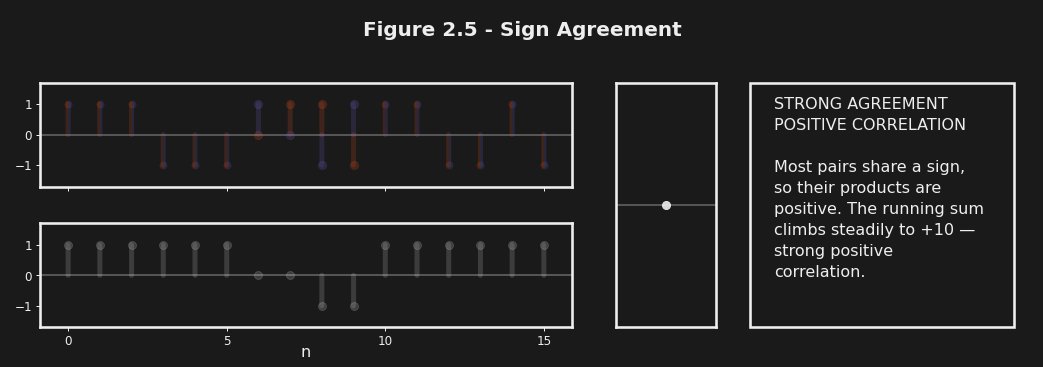

In [6]:
figure_2_5()

## 2.6 Basis Functions - Full Signal Decomposition

- In its raw form, a signal's properties are all mixed together - we can't see or work with any of them individually
  - To separate what's been entangled, we need a way to measure each property on its own - this is exactly what the Dot Product allows us to do
  - It compares two sets of values - measuring how much of one pattern exists within the other
    - One set is the audio signal
    - The other is a reference function — a pattern that embodies the property we want to measure
  - To measure for a **particular frequency**, we make the reference function a **pure sine wave** oscillating at that frequency - **Figure 2.6**
  - This is the goal of **full signal decomposition** — break down a signal into all of its parts by measuring the properties embodied in a set of reference patterns

- To do this **completely** and **non-redundantly** — no information lost, no information double-counted
  - We transform the signal into a format where every property has been independently accounted for
  - Transforming **N independent samples** in time into **N independent measurements** in frequency — preserving equivalent amounts of information in the new format
  - This set of N reference functions is called a **basis**

- Creating a sinusoidal basis transforms the signal into a format where we can see the presence of each frequency
  - By completely representing all information, we preserve the ability to **reconstruct** the original
  - How do we pick the specific frequencies? → Section 3

In [ ]:
figure_2_6()


## 3. Fourier Analysis - Frequency Representation

### 3.1 Sampling Rate and Duration

- To create a complete frequency representation - really just a bunch of dot products with different frequencies - we need to understand what we can measure in the first place

- **Sampling rate** controls how far apart each sample is spaced in time
  - We only have snapshots at each sample time - we can't know what's going on between samples
  - To detect a frequency, you need at least two samples per cycle - **Nyquist limit**
  - Audio is sampled at 44.1kHz - ceiling at ~22kHz
  - **Figure 3.1.a** - continuous signal with samples overlaid, the invisible gap

- **Duration** controls how finely we measure frequencies below the ceiling
  - To measure 1Hz, you need 1 second - one complete cycle
  - This is the lowest measurable frequency - the **fundamental** (1/duration)
  - To distinguish 10Hz from 11Hz, you need enough time for them to diverge
  - **Figure 3.1.b** - 10Hz vs 11Hz, short duration: identical, longer: clearly different




### 3.2 Building the Orthogonal Basis

- Integer multiples of the fundamental fill the range from floor to ceiling
  - 1Hz vs 2Hz: half the time they agree in sign, half they disagree - cancels to zero
  - Same for all integer multiples - sign agreement always balances out
  - Callback to §2.4.1: same **orthogonality**, now at the function level
  - **Figure 3.2.a** - 1Hz vs 2Hz, 1Hz vs 3Hz sign cancellation

- N orthogonal frequencies for N samples = complete, non-redundant basis
  - **Figure 3.2.b** - 5Hz + 0.1 amp 10Hz, only those bins light up




### 3.3 The Stationarity Assumption

**GAP TO CALL OUT:** We need to bridge from "we have a perfect basis" to "but it breaks in practice" - the bridge is: this works great for signals whose frequencies don't change. Real audio changes.

- The Fourier transform completely turns time-domain data into pure frequency information - but we lose all concept of *when*
  - The basis functions (sine waves) assume the frequency exists the **entire time** of the window
  - A sine wave in reality exists forever - its frequency is persistent - we're only computing it for one window
  - So the DFT measures *what frequencies exist in the window you gave it* - not when they happened

- What happens when a frequency changes **during** the window?
  - The dot product accumulates evidence in the first half when the frequency is active
  - After it goes away, it stops accumulating - the result is half as strong
  - When reconstructing, it takes that value and assumes the frequency existed throughout - reconstructing a half-strength sine wave across the entire window
  - This is inaccurate - the frequency was full-strength for half the time, not half-strength for all the time

- **Figure 3.3.a** - two signals, same spectrum (callback to ataspinar concept). Signal A: four frequencies simultaneously. Signal B: same four, one per quarter. Identical spectrums.

- **Goal visual** - 3D spectrogram of the chirp from Figure 1, GIF showing the dot product being assessed at each point in time




### 3.4 STFT and the Resolution Tradeoff

- So what do we do? We take the DFT **multiple times**
  - After the window: place the next window right after, no overlap - chunk the signal into moments of time
  - During the window: overlap the windows by some amount - a little redundant (overlapped part measures same signal twice) but worth it for a smoother representation

- But what about the edge effects?
  - The stationarity assumption implies the signal is one period of itself
  - When the edges are non-zero, we accumulate evidence of energy (or lack of) that skews results
  - Apply a **Hanning window** to taper edges - reduces artifacts but affects overall energy
  - Smart windowing helps: placing the peak of one frame's window over the edge of the other
  - Plant flag: this is a form of **shaping the analysis window** - becomes important for wavelets

- What about adjusting the window size?
  - **Shorter window**: you've limited the lower range (higher fundamental), fewer samples = fat blocky resolution, many frequencies per bin - accurate, just not high-definition
  - **Longer window**: do you extend the sine wave? It stops mid-cycle, skewing correlation. Do you scale it? You've stretched the frequency - it doesn't measure the same thing anymore
  - So you pick a window size to measure the lowest frequency you want - and stick with it

- This is the fundamental tradeoff
  - No matter what window you pick, it's ideal for one end and not the other
  - Tune for better high-frequency resolution → low frequencies suffer
  - Tune for better low-frequency resolution → high frequencies suffer
  - **Figure 3.4.a** - same signal, wide vs narrow STFT windows showing the tradeoff

- What if the window **adapted** to the frequency? → Section 4




### 3.5 Convolution Theorem

- FFT computes same N dot products in O(N log N) instead of O(N²) by reusing redundant math
  - Same answers, same dot products, just faster
- Correlation in time = multiplication in frequency domain
  - CWT uses this same trick
- No visual needed


## GAPS IDENTIFIED:

1. **2.6 → 3.1 bridge**: Currently solid - "how do we pick the frequencies" → "understand what we can measure first"

2. **3.2 → 3.3 bridge**: Need to say "this basis works perfectly for stationary signals - but real audio isn't stationary"

3. **3.3 → 3.4 bridge**: Need to explicitly say "we need time localization - the STFT gives us that, but introduces new problems"

4. **Visual: 3D spectrogram GIF**: Where does it go? Probably 3.3 or 3.4 - showing the row-by-row, column-by-column construction of the STFT, then reused for CWT with variable window length

5. **Edge effects**: Currently in 3.4 - should this be its own subsection or stay folded in? Given your preference for fewer sections, keep it folded.

6. **Convolution theorem placement**: 3.5 feels disconnected - could fold into 3.4 as a brief note, or keep separate as a short canonical beat that plants the flag for CWT.

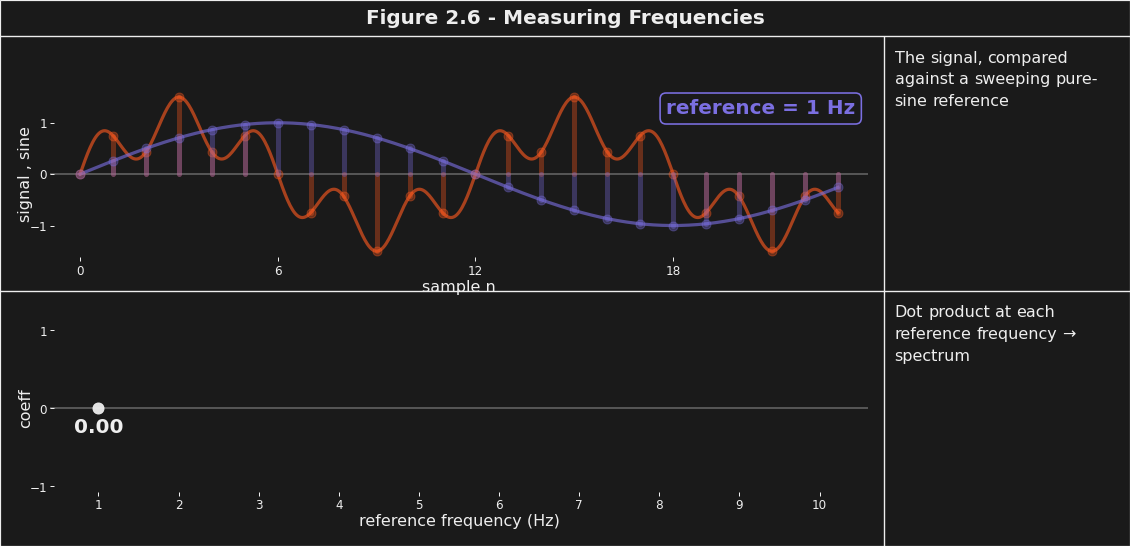

In [7]:
# figure_2_6()  # stale duplicate — relocated directly under §2.6 above



<!-- 

## 2.6 Basis Functions - Full Signal Decomposition

- Choosing a set of functions to completely represent all the properties we're interested in measuring is how we acheive full signal decomposition
   - In its raw form, a signal's properties are all mixed together - we can't see or work with any of them individually
   - Signal decomposition separates what's tangled
     - Re-representing all the information in a different, more convenient form
     - This is the entire point of everything we've been building - the Dot Product, correlation, sign accumulation - all of it serves this goal
   - We're no longer working with plain vectors - we're working with **sets of independent values**
     - The audio signal is one set
     - A reference function encoding a property we want to measure is the other

- Example: measuring frequencies with sine waves
   - To analyze a signal for a **particular frequency**, we make the reference function a pure sine wave oscillating at that frequency
     - The Dot Product tells us whether that frequency is present in the original signal - **Figure 2.6**
     - This is how frequency, a signal property embodied in our reference function, gets measured by the Dot Product
   - And what if a signal contains **multiple frequencies** and we wanted to measure more than just one?
     - Perform the Dot Product multiple times with sine functions at different frequencies
     - Each Dot Product result measures the presence of each frequency

- From measurements to a basis
   - What we're really trying to do is **completely represent** all the information in the original signal
     - If we're not careful about which frequencies we choose, we could measure the same information more than once
   - For a complete and **non-redundant** representation, each reference function must measure something the others don't
     - A set that achieves this is called a **basis**
     - Each function is **orthogonal** to the others
   - This allows us to view and work with the signal in a more convenient format
     - Using sine waves as a set of basis functions will show us which frequencies are present in the original
     - While preserving the ability to **reconstruct** it back to the original
   - For frequency analysis, sinusoidal basis functions are the natural choice - but which frequencies do we pick? → Section 3

## 2.6 Basis Functions - Full Signal Decomposition

- We're no longer working with plain vectors - we're working with **sets of independent values**
  - One of these sets will be the audio signal we are analyzing 
  - The other set will be a reference function containing the properties we are interested in measuring 
  - The result of their Dot Product is a singular correlation result - a measurement of how much of that property is present in the audio

- To analyze a signal for a **particular frequency**, we could make the reference function a pure sine wave oscillating at that frequency
  - Performing the Dot Product tells us whether or not its frequency is present in the original signal - **Figure 2.6**
  - This is how a signal property emobodied in a reference function gets measured by the Dot Product 

- But what if a signal contains **multiple frequencies**?
  - To measure them each, we perform the Dot Product multiple times with several different sine functions 
  - Each one measures the presence of a different frequency 

- What we're really trying to do is **completely represent** all the information in the original signal
  - Each Dot Product with a different sine wave measures the presence of a different frequency
  - But if we're not careful about which frequencies we choose, we could measure the same information more than once 
  - For a complete and **non-redundant** representation, each reference function must measure something the others don't
  - A set of reference functions that achieves this is called a **basis** - each function is **orthogonal** to the others, similar as before

- This is how we accomplish full **signal decomposition** - re-representing all the information from the original in a different form
  - Doing this allows us to work with the signal in a more convenient format, while preserving the ability to **reconstruct** it back to the original 
  - For frequency analysis, creating a set of sinusoids for a basis is the natural choice -->

<!-- - What we are trying to do here is completely represent all the information in the original audio
- This allows us to measure a collection of Dot Product results - comparing the same audio signal with multiple sine-wave reference function
  - But what is this really doing?
    - We're really creating a set of functions that represent all the properties aligned with each frequency - ehh i don't like how this sound
    - How do we decide which frequencies to include in our set?
      - We have the choice to use any and all frequencies we are interested in measuring, but if we're not careful, we could actually redundantly represent information in the original
      - Each function, like the individual components from earlier, need to measure information in the original that the others don't - if they overlap, we capture the same information redundantly

  - A set of reference functions that satisfies this is called a **basis**
    - Each basis function is orthogonal to the others - together they produce a **complete**, **non-redundant** representation
    - This is signal decomposition - and for frequency analysis, sinusoidal basis functions are the natural choice


### 2.6 Basis Functions - Achieving Signal Decomposition
- so as we are expanding our intuition, we need to think about why we are doing any of this in the first palce
- we are trying tie this all back to being able to look at a signal, and figure out what frequencies are being played
- so we need a way to meausre the signal and measure the presence o

- Accomplishing this really depends on the signal being analyzed and the properties we're interested in measuring
- The function we compare against is called a **basis function** - a known reference **pattern**
- The choice of basis function determines what features we can detect
- The scalar result of this comparison is called a **coefficient** - it tells you "how much" of that basis function is present

<!-- FIGURE relocated here from §2.4 per the consolidation pass - once §2.6
     is being authored, place the tip-to-tail recombination panel where it
     reinforces "components form a basis": the same components recombined
     in different orders both reconstruct a, which is exactly the property
     a basis function family relies on.
     ![Same components recombined tip-to-tail in opposite orders both reconstruct a](../../../assets/images/dsp/figures/vector_xy_reconstruction/baseline.png)-->

<!-- This is all about re-representing **all the information** from the original signal into a **different format**, while also being able to perform the **reverse process** to **reconstruct** the original   -->


<!-- ## 3. Fourier Transform: Sinusoidal Basis Functions --> 


<!-- ---

- At this point, we are no longer treating these "things" as "vectors" but instead sets of independent values
    - When we were working with vectors, we treated them as sets of independent dimensional components
    - Now we are treating them as functions - sets of independent values
  - One of these sets will be the audio signal function we are analyzing 
  - The other set will be a reference function containing the properties we are interested in discovering 

- To measure the presence of something inside something else, we first need to **define what that something is**
  - How do we do that
  - Tying us back to our decomposition criteria, we need to ensure 
  - Each value represents unique, non-overlapping information, so no information from the whole is captured redundantly
  To do that, we compare against a known reference pattern called a **basis function**



  * The result of this comparison is a **coefficient** - a scalar telling us *how much* of that pattern is present

* But we are not interested in measuring isolated pieces alone

  * We want to re-represent **all of the information** from the original signal in a different form
  * And critically, we want to be able to **reconstruct the original**

* This means our basis functions must satisfy two important requirements

  * They should measure **independent things**
  * Together, they should completely represent the original information

* This brings us back to our original motivation

  * If our goal is to understand what **frequencies** are present in a signal, we should probably choose basis functions that themselves embody **frequency** -->


### 3.1 Building the Sinusoidal Basis

- In recorded audio, samples are taken at regular intervals in time - this is its **sampling rate**
  - The sampling rate controls how far apart these samples are spaced in time - any information that occurs in between each sample cannot be measured
  - To detect a frequency, you need at least **two samples per cycle** - this is the [Nyquist Theorem](link)
  - Audio is typically sampled at 44.1kHz - putting our upper frequency limit at ~22kHz as a fixed constraint

- The **duration** of the signal controls how finely we measure frequencies below that ceiling
  - To measure 1 Hz, we need enough samples to complete cycle one cycle - 1 second. This is our lowest measurable frequency, the **fundamental** (1/duration) and all frequencies we measure are relative to it
  - To distinguish 10Hz from 11Hz, we need enough time for them to diverge - at first they look identical, but given enough duration, they decorrelate
  - Longer duration = finer frequency spacing

- Spacing our frequencies at **integer multiples** of the fundamental makes them **orthogonal**
  - Correlating the fundamental with its 2nd harmonic - half the time they agree in sign, half they disagree - cancels perfectly to zero
  - Same for all integer multiples - the sign agreement always balances out
  - Callback to §2.4.1: "measuring one tells you nothing about the others" - same **orthogonality**, now at the function level
  - N samples → N orthogonal frequencies → **complete**, **non-redundant** representation

## 3. Fourier Analysis - Frequency Representation

### 3.1 Sampling Rate and Duration
- Sampling rate sets the ceiling (Nyquist). Duration sets the floor and spacing (fundamental)
- Together they determine how much information exists: N samples = N independent measurements
- **Figure 3.1.a** - invisible gap between samples
- **Figure 3.1.b** -`10Hz vs 11Hz diverging over duration

### 3.2 Building the Orthogonal Basis
- Integer multiples of fundamental fill the range - orthogonal because sign agreement cancels
- N frequencies for N samples = complete, non-redundant representation
- **Figure 3.2.a** - 1Hz vs 2Hz, 1Hz vs 3Hz sign cancellation
- **Figure 3.2.b** - 5Hz + 0.1 amp 10Hz, only those bins light up

### 3.3 The Stationarity Assumption
- DFT assumes every frequency exists throughout the entire window - no *when*
- Callback to §1: chirp and clicks
- **Figure 3.3.a** - two signals, same spectrum

### 3.4 STFT and the Resolution Tradeoff
- Slice into windows, but fixed window = fixed tradeoff
- Edge artifacts → window functions smooth them
- What if the window adapted? → Section 4
- **Figure 3.4.a** - wide vs narrow STFT

### 3.5 Convolution Theorem
- FFT: O(N log N) instead of O(N²). CWT uses same trick.
- No visual

## 3.1 - Building the Sinusoidal Basis

To pick the specific frequencies, we need to understand how a signal's sampling rate and duration constrain which frequencies we can measure

**Beat 1 - Sampling rate sets the ceiling**
- When you record a signal, its samples are taken at regular intervals in time - this called its **sampling rate**
- Each sample value is a snapshot of the signal at a particular moment in time 
- The sampling rate defines how often we take these samples, and intrinsicly controls how wide apart these samples occur in time
- This very spacing defines the limit for the highest frequency we can measure
- Any information that occurs in between each sample cannot be measured - this is the Nyquist Limit in action
- Any information that occurs in between each sample, regardless of what it may be doing, our sample rate it when it takes a sample, only takes two values, 
- So when we say we are measuring for all the frequency information, we are actually just saying we are measuring all the frequency information taht we can
- Any information that would exist in between these samples, would be too fine of detail to capture
- We could capture it with a higher sample rate - sample more frequently, reduce the space between each sample, but we could do this forever until we have a bajilion samples to process
- There is an upper limit which ismore than good enough to capture all the audio information we would need - people ususllay say 20-20k -
- nyquist - two samples per cycle, so we would need like 40k zamples for 20k, good thing for us, audio is sampled at 44.1k for exactly this reason
- this puts our upper limit at 20.5k and fixes our resolution as a constant constraint

- **Figure 3.1.a** - continuous signal with samples overlaid, show the invisible gap, show a high-frequency oscillation missed between samples

**Beat 2 - Duration determines frequency resolution**
- The length of the signal - using that dot product and a basis to analyze a signal - controls how finely we will measure frequencies up to our nyquist limit
- Mathwise when we transform data from the time domain to the frequency domain, we represent all the information in a new format - instead of n time values, we create n values frequency "coefficients" (special name for just "transformed set of values")
- To measure a frequency, like 1 Hz, we need enough samples for one 1 Hz sine wave to complete one cycle
- Otherwise we'd be doing the dot product of an incomplete sine wave or...
- Since this is longest wavelength we can fit, this is going to be the lowest frequency we can measure - this called the root harmonic - we can't measure anything below this
- This is just one way of looking at it, but it helped me understand how we define our resolution
- It turns out, ooooh maybe we should start with this - it turns out, if we double the freqeuncy, the dot product between the root note and its second harmonic is zero - meaning they are uncorrelated - meaning they are orthogonal to each other - meaning they measure independent information about the signal 
- This is like take the dot product between vectors at right angles, each component's agreement cancels out perfectly to produce no similarity but more importantly,no relation
- And if we even divided the root frequency in three - tripling it frequency, we would also find out that they have no correlation, and they are indepdent of each other, and they measure independent properties about the signal 
- So if we play with signal constraints, singal duration, and consider its sampling rate, we can choose frequencies that we are interested in measuring
- At 44.1k samples, we can measure up to 20.05 khz, and if we only care about signals between 20 - 20 kHz, I would just go to our lowest frequency, determine how long it takes for a 20 hz sine wqve to cycle once, and use that as my signal length 
- To distinguish two close frequencies, we need enough samples to have them diverge - think of 10 vs 11 Hz, at first they seem to oscillate pretty similar - highly correlated at first, large dot product result - but eventually, they diverge and start being completely uncorrelated
- Given your ceiling, duration determines how finely you can distinguish close frequencies
- To measure a 1Hz frequency, you need at least 1 second - that's how long one cycle takes
- To distinguish 10Hz from 11Hz, you need enough time for them to diverge
- Longer duration = finer frequency bins
- The lowest frequency you can measure is 1/duration - you can't measure what doesn't complete a full cycle
- **Figure 3.1.b** - 10Hz and 11Hz sinusoids. Short duration: identical. Longer duration: clearly different.

**Beat 3 - Integer multiples of 1/duration create orthogonality**
- Space your frequencies at integer multiples of the fundamental (1/duration)
- When you correlate 1Hz with 2Hz over one second: half the time they agree in sign, half they disagree - cancels to zero
- This pattern holds for all even multiples (2Hz, 4Hz, 6Hz...) - half agreement, half disagreement
- Same for odd multiples (3Hz, 5Hz, 7Hz...) - asymmetric but still balanced, still cancels
- This is where orthogonality comes from - integer multiples are guaranteed to cancel
- Callback to §2.4.1: "measuring one tells you nothing about the others"
- **Figure 3.1.c** - 1Hz vs 2Hz correlation (show sign agreement/disagreement, running sum to zero). 1Hz vs 3Hz (same thing, still cancels).

**Beat 4 - Complete representation**
- N samples → N basis functions at orthogonal frequencies → N independent results
- Each captures a unique piece of information
- Together: complete, non-redundant representation
- Can reconstruct the original by scaling each basis function by its result and adding them together
- **Figure 3.1.d** - 5Hz (amplitude 1.0) + 10Hz (amplitude 0.1). Dot products across all bins. Only 5Hz and 10Hz light up. Everything else zero.


## 3.2 - The Stationarity Assumption

This decomposition works perfectly - but it makes an assumption about the signal.

**Beat 1 - DFT assumes every frequency exists throughout the entire window**
- The reference functions (sinusoids) oscillate at a constant frequency for the entire duration
- When you correlate, you're asking "how much of this frequency is present across the whole window?"
- There's no temporal information - just "this frequency exists" with no *when*
- If a frequency only exists for part of the window, or changes midwayfigure_2_6()

### 3.1 Sinusoidal Basis

---

## 3. Fourier Analysis - Frequency Representation

### 3.1 Building a Sinusoidal Basis

**Beat 1 - Which frequencies do we pick?**
- Callback to §2.6: we need a complete, non-redundant set of sine waves - first we need to understand the constraints we're wrokking iwth
- time duration of the singal and sample rate
- Our signal is a set of values sampled in time - the spacing between samples limits the finest detail we can capture
- Anything happening between samples is invisible → Nyquist sets the ceiling (link, don't deep-dive)
- Signal length determines frequency resolution - to distinguish close frequencies (100Hz vs 101Hz), you need enough samples to see where they diverge
- **Figure 3.1.a** - two close-frequency sinusoids that look identical early but diverge with enough samples

**Beat 2 - Orthogonality in action**
- Frequencies spaced at integer multiples of 1/duration are orthogonal - each bin measures only its own energy
- **Figure 3.1.b** - signal: 5Hz (amplitude 1.0) + 10Hz (amplitude 0.1), 100 samples, 1 second
  - Dot product results across all bins
  - Only 5Hz and 10Hz light up, proportional to amplitude
  - Everything else zero
- Callback to §2.4.1: "measuring one tells you nothing about the others" - same principle, function level

**Beat 3 - Complete representation**
- N samples → N basis functions → N results
- Each result captures a unique, independent piece of information
- Together: complete, non-redundant representation of the original
- Inverse transform reconstructs the original perfectly - nothing lost, nothing double-counted


<!-- At this point we have an operation that can measure the signal properties we are interested in measuring 
and a goal of completely representing the original signal using these properties using a set of basis functions

Last sectoin we said we need to specifically pick the referene functions so they accurately represetn tht eoriginal's information

So how exactly do we do this

The Fourier Transform uses sinusoids to represent all the information in a signal - we say sinusoid instead of sine wave because its more than that but for now we'll stick with sine waves

So when we go to pick the frequencies - which ones? We could try all of them? What is all of them, well thats determined by NyQuist 

but if we did all the way up to the nyquist, we would get a lot of redundant information? why? discrete values, if it were continuous, it'd be different story

but we're in discrete land, so since these truly as just values, what kind of values are they? they're measuremetns ampledin time, so they have a width a part - dictated by how often we take a sample - sampling frequency, reducing how often we sample is the same thing as spacing these samples far apart in time

this affects the upper limit of frequencies we can measure nyquist link explaining this

this is the nyquist law we abide by in discrete - we have to consider how spaced apart these measurements are taken becauase we can't capture information from the signal more finely than that - so properties that are represented by information that would be captured between those points can't be measured - this actually gives us aliasing - measuring for a more higher frequency property will incorrectly measure information measured by other basis functions

also, heres why theryre binned, the width o feah bbin is dictaed by the smapling rate, and the bin is only measured by a single reference function - heres an exmaple of reducnta measure - heres example of complete represenetation -->

<!--
## 3. Fourier Analysis - Frequency Representation
-->

<!--

# DSP Documentation Outline - Sections 3 & 4

---

### 3.2 The Stationarity Problem

**Beat 1 - DFT assumes the signal repeats forever**
- Every frequency detected is assumed present throughout the entire signal
- No temporal information - just "this frequency exists" with no *when*
- Callback to §1: this is why the STFT visualization struggled with the chirp sweep and clicks

**Beat 2 - Two signals, same spectrum**
- **Figure 3.2.a** - Signal A: four frequencies present simultaneously. Signal B: same four frequencies but each in a different quarter of the signal. Identical spectrums. DFT can't tell them apart.
- This is the fundamental limitation: DFT collapses all temporal information

**Beat 3 - STFT: adding time**
- Solution: apply DFT in sliding windows - now you get frequency info *at each time position*
- But chopping the signal into windows creates edge artifacts - the signal abruptly starts and stops at window boundaries
- Window functions (Hann, etc.) smooth the edges to reduce leakage
- Plant flag: "this is a form of shaping the analysis window, which becomes important for wavelets"

---

### 3.3 The Resolution Tradeoff

**Beat 1 - Fixed window = fixed tradeoff**
- Wide window: good frequency resolution, poor time localization (you see frequencies clearly but don't know exactly *when*)
- Narrow window: sharp timing, smeared frequencies (you know *when* something happens but not exactly *what*)
- You can't have both simultaneously - this is fundamental, not a limitation of the algorithm
- **Figure 3.3.a** - same signal analyzed with wide vs narrow STFT windows. Wide: clean frequency contours, blurry timing. Narrow: sharp transients, smeared frequencies.

**Beat 2 - The question CWT answers**
- What if the window adapted to the frequency? Wide for low frequencies (where frequency resolution matters more), narrow for high frequencies (where timing matters more)
- That's exactly what the wavelet transform does → Section 4

---

### 3.4 Computational Efficiency - The Convolution Theorem

**Beat 1 - The speed problem**
- Computing all N dot products directly is O(N²) - slow for large signals
- The FFT algorithm computes the same N results in O(N log N) by exploiting symmetry - it notices many multiplications are redundant and reuses intermediate results
- Same answers, same dot products, just avoids redundant math

**Beat 2 - Correlation via frequency domain**
- Convolution theorem: correlation in time = multiplication in frequency domain
- Transform both signals to frequency domain (FFT), multiply, inverse transform back
- For symmetric basis functions (sinusoids, Morlet wavelets), magnitude is identical whether you correlate or convolve
- Plant flag: the CWT uses this same trick - correlating with wavelets via frequency-domain multiplication

---

## 4. Wavelet Analysis - Adaptive Time-Frequency Resolution

### 4.1 The Wavelet as a Basis Function
- Sinusoid shaped by a Gaussian envelope
- Callback to STFT windowing - the wavelet *is* the window
- No artificial periodicity assumption - the Gaussian naturally tapers to zero

### 4.2 Scaling the Wavelet
- Stretching for low frequencies, compressing for high
- This is where the adaptive resolution comes from
- Callback to §3.3: CWT answers the question STFT couldn't
- Wide wavelet (low freq) → good frequency resolution
- Narrow wavelet (high freq) → good time resolution

### 4.3 Sliding the Wavelet
- Correlation at every time position - this is where the "sliding" concept enters
- Callback to §3.1 where we explicitly said "Fourier doesn't slide"
- Each position gives one correlation result - stack all positions across all scales → time-frequency matrix

### 4.4 Overcomplete and Redundant
- CWT deliberately breaks orthogonality from §2.6
- Callback to the orthogonality flag: DFT and DWT preserve it, CWT trades it for smoother coverage and better edge resolution
- The redundancy is the feature, not the bug

### 4.5 Edge Effects and the Cone of Influence
- Callback to STFT windowing artifacts from §3.2
- Wider wavelets (low freq) extend further beyond signal boundaries → more edge contamination
- The cone of influence marks which results are reliable

---

## Visuals Summary

| Figure | Section | What it shows | Why it matters |
|--------|---------|---------------|----------------|
| 3.1.a | 3.1 | Two close sinusoids diverging over time | Signal length = frequency resolution |
| 3.1.b | 3.1 | 5Hz + 10Hz signal, dot products across all bins | Orthogonality payoff - only matching bins light up |
| 3.2.a | 3.2 | Two signals, same spectrum | DFT collapses temporal information |
| 3.3.a | 3.3 | Wide vs narrow STFT windows on same signal | The resolution tradeoff made visible |
| 3.4 | 3.4 | None needed | Just acknowledge the speedup exists |
| 4.1 | 4.1 | Morlet wavelet - sinusoid × Gaussian | The wavelet IS the window |
| 4.2 | 4.2 | Scaled wavelets at different frequencies | Adaptive window size |
| 4.3 | 4.3 | Wavelet sliding across signal | Time-localized correlation |
| 4.4 | 4.4 | DFT uniform tiling vs CWT adaptive tiling | Why redundancy gives better resolution |
| 4.5 | 4.5 | Cone of influence mask | Which results to trust |

---

## Callback Map

| Flag planted | Where | Called back | Where |
|-------------|-------|------------|-------|
| Orthogonality (independence) | §2.4.1 | Function-level orthogonality | §2.6, §3.1 |
| Orthogonality (independence) | §2.4.1 | CWT breaks orthogonality | §4.4 |
| Sign accumulation = correlation | §2.5 | Fourier = correlation with sinusoids | §3.1 |
| Basis = complete, non-redundant | §2.6 | DFT achieves this, CWT deliberately doesn't | §3.1, §4.4 |
| Fourier doesn't slide | §3.1 | CWT slides the wavelet | §4.3 |
| STFT window shaping | §3.2 | Wavelet IS the window | §4.1 |
| Fixed resolution tradeoff | §3.3 | CWT adapts the window | §4.2 |
| Convolution theorem | §3.4 | CWT uses same trick | §4.3 |
| STFT edge artifacts | §3.2 | Cone of influence | §4.5 |
| Chirp/clicks motivation | §1 | DFT can't capture them | §3.2 |
| Chirp/clicks motivation | §1 | CWT handles them | §4.2 |
-->

<!--
okay, so so far we'vwe established how the duration and sampling rate affects thesresolution - depends on these two constraints, but in reality, the sampling frequecny is already handed to us as the sampling rate og the audio we are analyzing - audio is typically always recorded at 44.1k hz - this is important to know - becuase of nyquist theory, we are only able to tryuly measure up to 22.05k hz - which is fine for us - we are tryiung tobisualize the audio you can hear, and the hearing range is about 20 - to 20k hz -  so these are our limits - this is a fine sampling rate to work with - no need to process signal information we can't hear - however, this leaves us witht the duration - how many sample should we even be looking at? well - at 44.1k hz, there are 44,100 samples per second, so if we wanted to measure for one hz, we would need enough of the signal for one cycle to complete - 44100 samples - but like we said, we can't really hear anythign below 20 hz, and in reality its really more like 50 hz (low sub bass rumbles) so we can get away with processing with less - 

this base frequency is called the first harmonic - all other mesurements are scaled multiples of it - using our nyquist frequency, we know waht our upper limit is
anything lower in frequency will get binned into the fundamental, this like the dc offset in dsp terms,

everything else will be measured in evenly spaced bins of frequency resolution - 

so  at this point - we know how to control the resolution at which we are able to finely measure for frequency - we now know how to do it in a complete representation way

heres the issue - what where to happen if while a a low tone was oscillating while simultaneously, a high note were playing, and then half way through, the high note stops

well, the thing is, the fft assumes periodic anture




so heres the first real limitation of the classic fourier transform 
 fourier is great at measuring what frequencies are present in the signal you are measuring
its one of the most useful discoveries in math in the last 150 year
the only issue is, it can tell what frequencies are present in your signal, but it can't tell you when 
when we transform a signal from the time domain to the frequency domain, we are completely lose all information related to time
the frequency in the sine wave pattern exists throughout the entirety of the shape - so this should completely make sense
there is not concept of time in the frequency domain - the only one being the frequency we're measuring exists some amount for the entire 
duration of the signal 
-->

/home/eddie-water/dev/python/sub-shader/src/subshader/dsp/../../../research/dsplot/plottables/stem.py:94: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min, x_max)


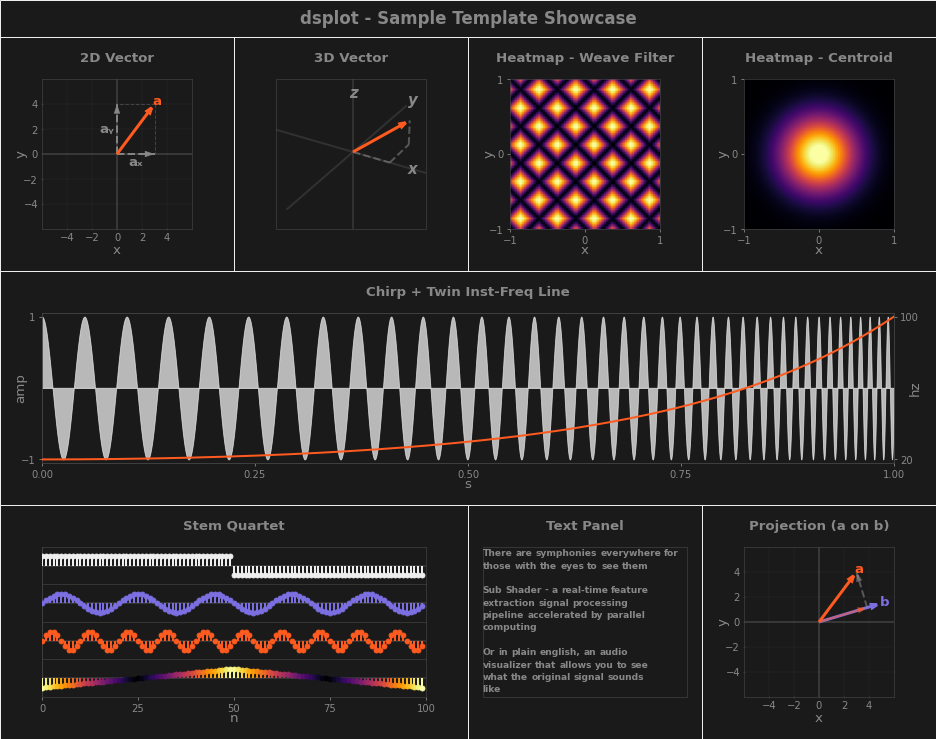

In [8]:
# dsplot - Sample Template (kitchen-sink showcase)
# from dsplot.figures import sample_template
# sample_template.show()


In [9]:
# import sys
# _purged = [m for m in list(sys.modules) if m == "dsplot" or m.startswith("dsplot.")]
# for _m in _purged:
#     del sys.modules[_m]
# from dsplot.figures import figure_1, figure_2_4_1, figure_2_4_2
# import dsplot
# print("purged", len(_purged), "dsplot modules")
# print("has DynamicTextPanel:", hasattr(dsplot, "DynamicTextPanel"))
# print("has RichText:", hasattr(dsplot, "RichText"))
# print("content border inset:", dsplot.style.DEFAULT_CONTENT_BORDER_INSET_FRAC)
# print("figure_2_4_2 module:", figure_2_4_2.__module__)


purged 43 dsplot modules
has DynamicTextPanel: True
has RichText: True
content border inset: 0.0625
figure_2_4_2 module: dsplot.figures.gen_figure_242_a_onto_b


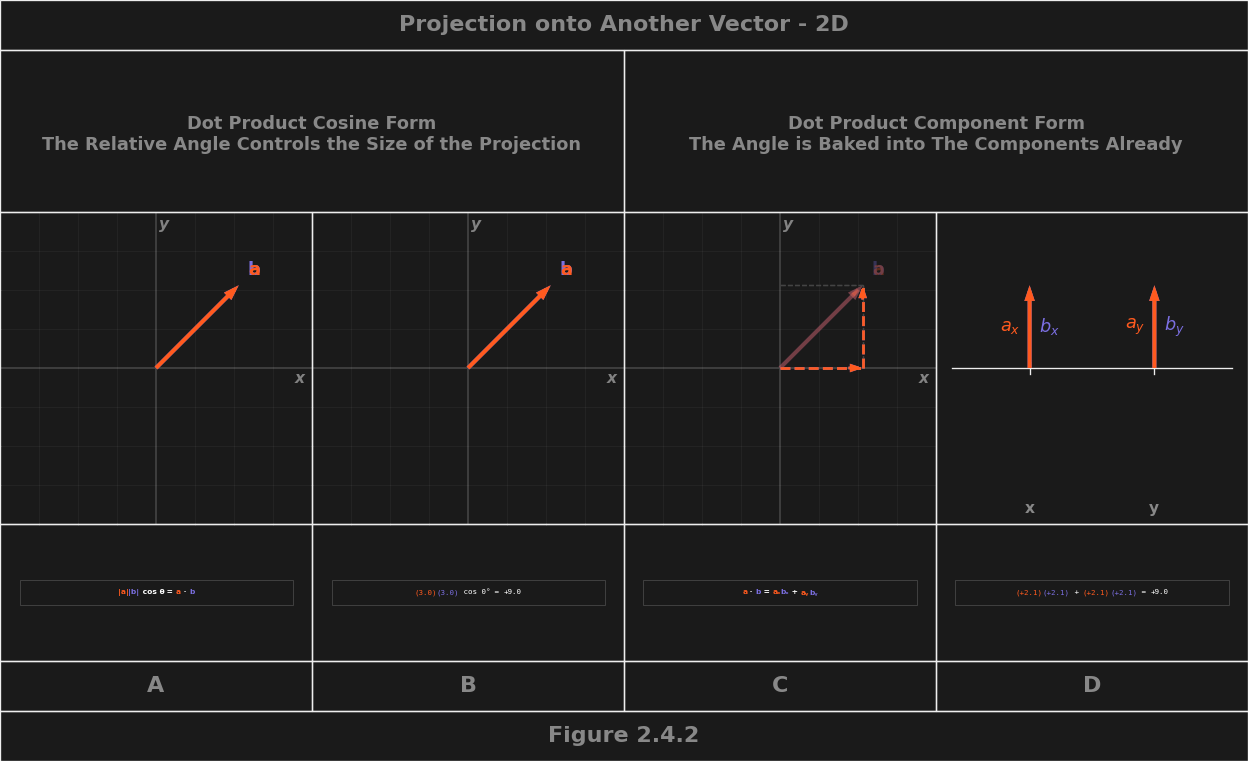

In [10]:
# figure_2_4_2()

purged 43 dsplot modules; reloaded figure_2_4_2


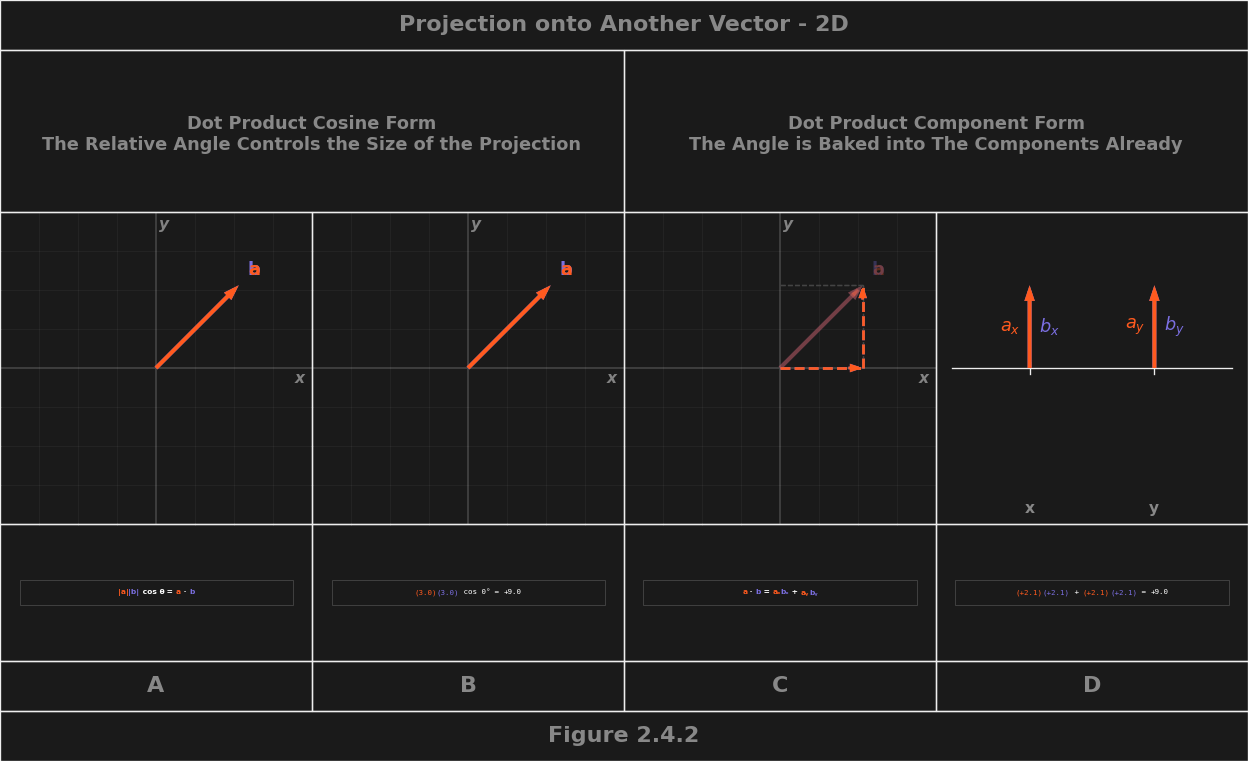

In [11]:
# import sys
# _purged = [m for m in list(sys.modules) if m == "dsplot" or m.startswith("dsplot.")]
# for _m in _purged:
#     del sys.modules[_m]
# from dsplot.figures import figure_2_4_2
# print(f"purged {len(_purged)} dsplot modules; reloaded figure_2_4_2")
# figure_2_4_2()

purged 43 dsplot modules; module -> dsplot.figures.gen_figure_242_a_onto_b


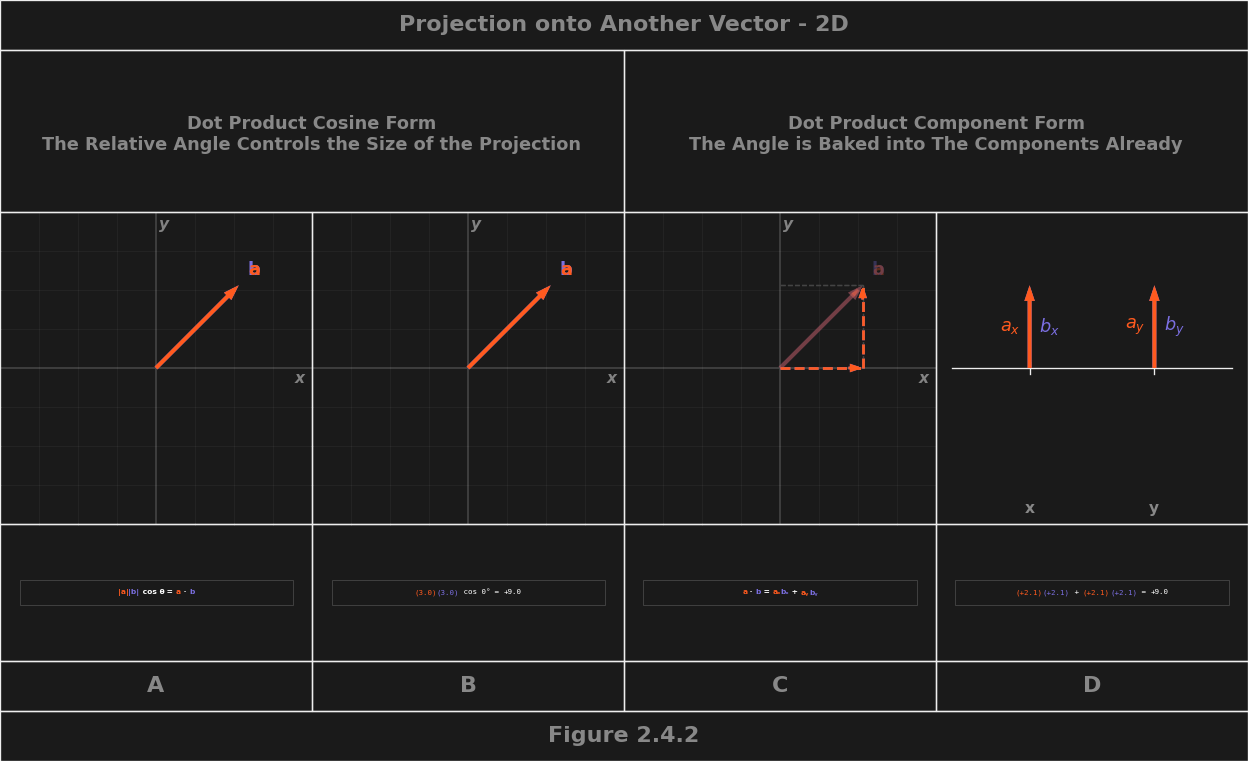

In [12]:
# import sys
# _purged = [m for m in list(sys.modules) if m == "dsplot" or m.startswith("dsplot.")]
# for _m in _purged:
#     del sys.modules[_m]
# from dsplot.figures import figure_2_4_2
# print(f"purged {len(_purged)} dsplot modules; module ->", figure_2_4_2.__module__)
# figure_2_4_2()